In [5]:
dir



<function dir>

In [7]:
DATA_DIR = Path(r"project\data_science_supply_chain_dataset")


In [8]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"project\data_science_supply_chain_dataset")  # or your real path

print("Looking in:", DATA_DIR)
print("Files found:", list(DATA_DIR.glob("*.csv")))


Looking in: project\data_science_supply_chain_dataset
Files found: []


In [9]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"project\data_science_supply_chain_dataset")

print("Looking in:", DATA_DIR)
print("Files found:", list(DATA_DIR.glob("*.csv")))


Looking in: project\data_science_supply_chain_dataset
Files found: []


In [11]:
import os
print(os.getcwd())



C:\Users\suman


In [12]:
import zipfile
from pathlib import Path

zip_path = Path(r"C:\Users\suman\Data Engineer.zip")
extract_to = Path(r"C:\Users\suman\Data Engineer")

extract_to.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_to)

print("Extracted to:", extract_to)
for p in extract_to.iterdir():
    print(p)


Extracted to: C:\Users\suman\Data Engineer
C:\Users\suman\Data Engineer\Data Engineer.pdf
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset.zip


In [13]:
inner_zip = extract_to / "data_science_supply_chain_dataset.zip"
dataset_dir = extract_to / "data_science_supply_chain_dataset"
dataset_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(inner_zip, "r") as z:
    z.extractall(dataset_dir)

print("CSV files:")
for p in dataset_dir.glob("*.csv"):
    print(p)


CSV files:
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_inventory_data.csv
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_products_master.csv
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_sales_data.csv
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_shipment_data.csv


In [14]:
from pathlib import Path
DATA_DIR = Path(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset")
OUT_DIR = Path(r"C:\Users\suman\processed")
OUT_DIR.mkdir(exist_ok=True)


In [19]:
import os
print(os.listdir())


['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Data Engineer', 'Data Engineer.zip', 'Data_analyst_supply_chain_project.zip', 'data_science_supply_chain_project.zip', 'Documents', 'Downloads', 'Favorites', 'final_supply_chain_analysis.csv', 'learn flu', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1bf12db1-b527-11f0-8135-a059503b2b9d}.TM.blf', 'NTUSER.DAT{1bf12db1-b527-11f0-8135-a059503b2b9d}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{1bf12db1-b527-11f0-8135-a059503b2b9d}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'processed', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'supply_chain_data.csv', 'supply_chain_project.ipynb', 'Templates', 'Untitled.ipynb', 'Videos']


In [20]:
import os
print(os.listdir(r"C:\Users\suman\Data Engineer"))


['Data Engineer.pdf', 'data_science_supply_chain_dataset', 'data_science_supply_chain_dataset.zip']


In [22]:
import zipfile
with zipfile.ZipFile(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset.zip", "r") as z:
    z.extractall(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset")

print("Extracted inner dataset!")
print(os.listdir(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset"))


Extracted inner dataset!
['ds_inventory_data.csv', 'ds_products_master.csv', 'ds_sales_data.csv', 'ds_shipment_data.csv']


In [25]:
from pathlib import Path

code = """# -*- coding: utf-8 -*-
from pathlib import Path
import pandas as pd

# Paths
DATA_DIR = Path(r"C:\\Users\\suman\\Data Engineer\\data_science_supply_chain_dataset")
OUT_DIR = Path(r"C:\\Users\\suman\\processed")
OUT_DIR.mkdir(exist_ok=True)

def clean_df(df):
    # Remove duplicates and empty rows
    df = df.drop_duplicates()
    df = df.dropna(how="all")
    return df

def main():
    print("Looking for CSV files in:", DATA_DIR)
    for f in DATA_DIR.glob("*.csv"):
        print("Reading", f.name)
        df = pd.read_csv(f)
        df = clean_df(df)
        out = OUT_DIR / (f.stem + ".parquet")
        df.to_parquet(out, index=False)
        print("Wrote", out)

if __name__ == "__main__":
    main()
"""

path = Path(r"C:\Users\suman\Data Engineer\etl_clean.py")
path.write_text(code, encoding="utf-8")

print("✅ Clean UTF-8 etl_clean.py created successfully!")


✅ Clean UTF-8 etl_clean.py created successfully!


In [26]:
!python "C:/Users/suman/Data Engineer/etl_clean.py"


Looking for CSV files in: C:\Users\suman\Data Engineer\data_science_supply_chain_dataset
Reading ds_inventory_data.csv
Wrote C:\Users\suman\processed\ds_inventory_data.parquet
Reading ds_products_master.csv
Wrote C:\Users\suman\processed\ds_products_master.parquet
Reading ds_sales_data.csv
Wrote C:\Users\suman\processed\ds_sales_data.parquet
Reading ds_shipment_data.csv
Wrote C:\Users\suman\processed\ds_shipment_data.parquet


In [27]:
import os
print(os.listdir(r"C:\Users\suman\processed"))


['ds_inventory_data.parquet', 'ds_products_master.parquet', 'ds_sales_data.parquet', 'ds_shipment_data.parquet']


In [28]:
import pandas as pd
from pathlib import Path

processed_dir = Path(r"C:\Users\suman\processed")

sales = pd.read_parquet(processed_dir / "ds_sales_data.parquet")
inventory = pd.read_parquet(processed_dir / "ds_inventory_data.parquet")
products = pd.read_parquet(processed_dir / "ds_products_master.parquet")
shipment = pd.read_parquet(processed_dir / "ds_shipment_data.parquet")

print("✅ Data loaded successfully!")
print("Sales shape:", sales.shape)
print("Inventory shape:", inventory.shape)
print("Products shape:", products.shape)
print("Shipment shape:", shipment.shape)


✅ Data loaded successfully!
Sales shape: (100000, 9)
Inventory shape: (100000, 6)
Products shape: (10000, 4)
Shipment shape: (100000, 7)


In [30]:
print("Sales columns:", sales.columns.tolist())
print("Products columns:", products.columns.tolist())


Sales columns: ['Order_ID', 'Order_Date', 'Product_ID', 'Customer_ID', 'Region', 'Quantity', 'Unit_Price', 'Discount', 'Total_Sales']
Products columns: ['Product_ID', 'Category', 'Subcategory', 'Price']


In [31]:
df = sales.merge(products, on="Product_ID", how="left")
print("Merged shape:", df.shape)
print(df.head())


Merged shape: (100000, 12)
  Order_ID  Order_Date Product_ID Customer_ID Region  Quantity  Unit_Price  \
0  O000001  2024-05-04     P00410       C9571   West         8     1240.51   
1  O000002  2023-01-02     P01917       C6636   East         2      186.97   
2  O000003  2024-06-11     P04068       C1804   East         1     1500.74   
3  O000004  2024-09-29     P02860       C2647   West        16      411.38   
4  O000005  2024-06-17     P07073       C2702  North        18     1895.57   

   Discount  Total_Sales     Category Subcategory    Price  
0      0.08      9130.15         Food   Groceries  1240.51  
1      0.30       261.76       Sports      Tennis   186.97  
2      0.01      1485.73       Sports      Tennis  1500.74  
3      0.20      5265.66     Clothing       Shirt   411.38  
4      0.30     23884.18  Electronics      Laptop  1895.57  


In [32]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")


In [33]:
sales_by_category = df.groupby("category")["total_sales"].sum().sort_values(ascending=False)
print(sales_by_category)


category
Electronics    1.749625e+08
Sports         1.738355e+08
Furniture      1.704338e+08
Food           1.678311e+08
Clothing       1.669175e+08
Name: total_sales, dtype: float64


In [34]:
avg_discount = df.groupby("subcategory")["discount"].mean().sort_values(ascending=False)
print(avg_discount)


subcategory
Shoes        0.151743
Sofa         0.150727
Frozen       0.150705
TV           0.150702
Beverages    0.150603
Snacks       0.150316
Football     0.150263
Mobile       0.150223
Table        0.150216
Tennis       0.150096
Laptop       0.150005
Bed          0.149985
Jeans        0.149973
Shirt        0.149811
Groceries    0.149762
Cricket      0.149756
Tablet       0.149328
Gym          0.149137
Chair        0.148929
Jacket       0.148846
Name: discount, dtype: float64


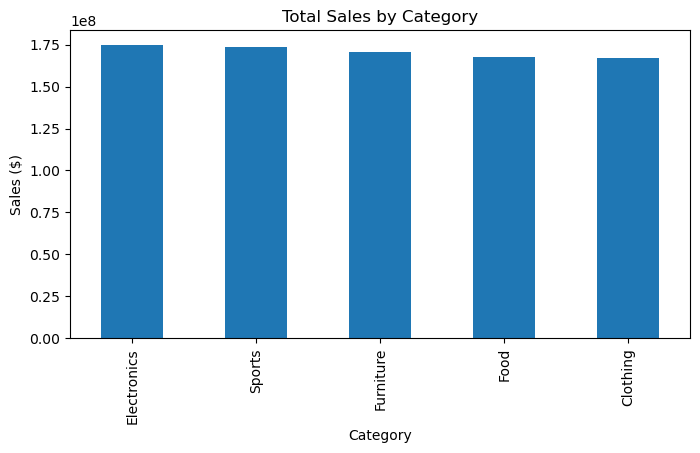

In [35]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind="bar", figsize=(8,4))
plt.title("Total Sales by Category")
plt.ylabel("Sales ($)")
plt.xlabel("Category")
plt.show()


product_id
P06277    365302.89
P03269    361135.38
P05238    355336.53
P05933    355044.34
P00369    351962.46
P06276    339165.14
P05462    338821.80
P06052    335334.34
P01805    328941.61
P05614    328474.16
Name: total_sales, dtype: float64


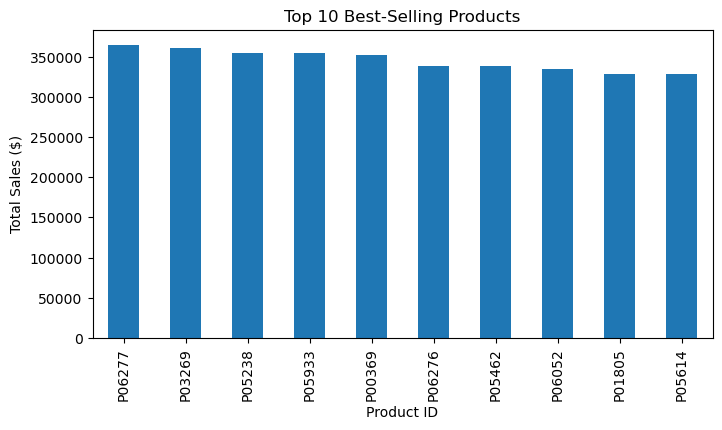

In [36]:
top_products = df.groupby("product_id")["total_sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

top_products.plot(kind="bar", figsize=(8,4))
plt.title("Top 10 Best-Selling Products")
plt.ylabel("Total Sales ($)")
plt.xlabel("Product ID")
plt.show()


region
South    2.145316e+08
North    2.134221e+08
East     2.131609e+08
West     2.128659e+08
Name: total_sales, dtype: float64


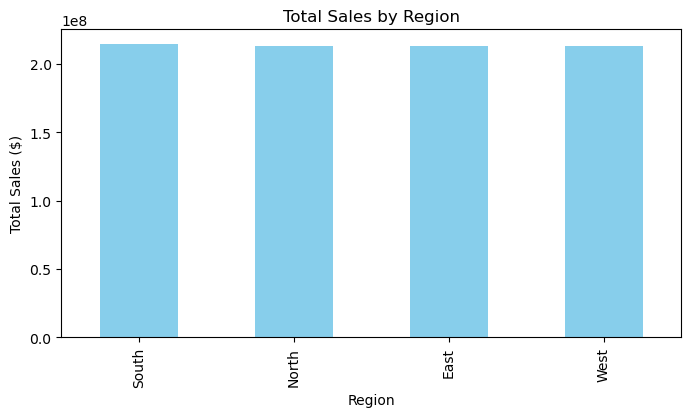

In [37]:
sales_by_region = df.groupby("region")["total_sales"].sum().sort_values(ascending=False)
print(sales_by_region)

sales_by_region.plot(kind="bar", color="skyblue", figsize=(8,4))
plt.title("Total Sales by Region")
plt.ylabel("Total Sales ($)")
plt.xlabel("Region")
plt.show()


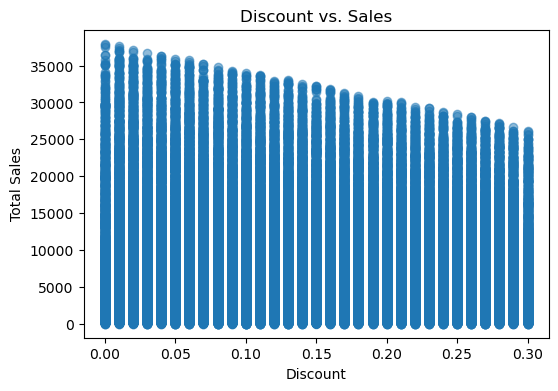

In [38]:
plt.figure(figsize=(6,4))
plt.scatter(df["discount"], df["total_sales"], alpha=0.5)
plt.title("Discount vs. Sales")
plt.xlabel("Discount")
plt.ylabel("Total Sales")
plt.show()


In [40]:
print(df.columns.tolist())


['order_id', 'order_date', 'product_id', 'customer_id', 'region', 'quantity', 'unit_price', 'discount', 'total_sales', 'category', 'subcategory', 'price']


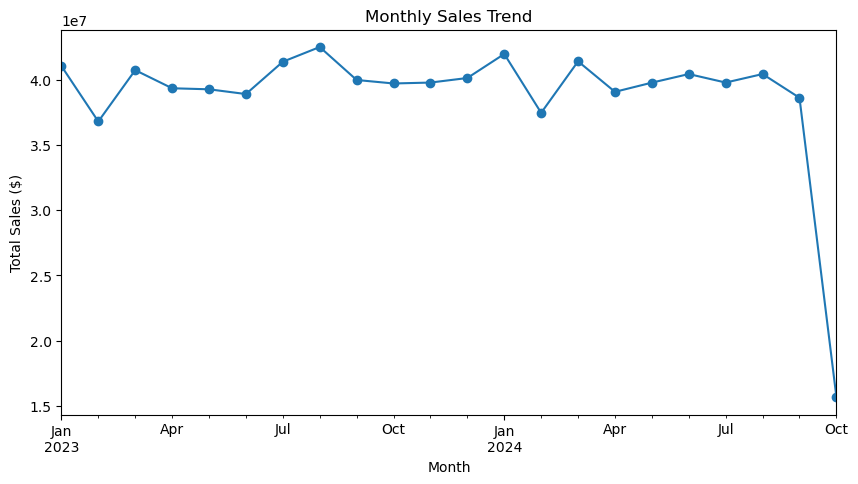

In [42]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Group by month and sum total sales
monthly_sales = df.groupby(df["order_date"].dt.to_period("M"))["total_sales"].sum()

# Plot the monthly trend
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales ($)")
plt.xlabel("Month")
plt.show()


In [43]:
print("Best Month for Sales:")
print(monthly_sales.sort_values(ascending=False).head(1))


Best Month for Sales:
order_date
2023-08    42493398.28
Freq: M, Name: total_sales, dtype: float64


In [48]:
from pathlib import Path

base = Path(r"C:/Users/suman/Data Engineer")

for path in base.rglob("*.csv"):
    print(path)


C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_inventory_data.csv
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_products_master.csv
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_sales_data.csv
C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_shipment_data.csv


In [49]:
shipment = pd.read_csv(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_shipment_data.csv")
print(shipment.head())


  Shipment_ID Order_ID Region Shipment_Date Delivery_Date     Status  \
0     S000001  O052979   East    2024-06-26    2024-06-30    Delayed   
1     S000002  O006590  North    2024-03-04    2024-03-05  Delivered   
2     S000003  O007224   West    2024-01-15    2024-01-20  Delivered   
3     S000004  O061909   East    2023-02-17    2023-02-24    Delayed   
4     S000005  O070287   East    2024-09-16    2024-09-21  Delivered   

   Delay_Days  
0           4  
1           0  
2           0  
3           4  
4           0  


In [50]:
import pandas as pd

shipment = pd.read_csv(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_shipment_data.csv")

print("✅ Shipment file loaded successfully!")
print(shipment.head())
print(shipment.columns)


✅ Shipment file loaded successfully!
  Shipment_ID Order_ID Region Shipment_Date Delivery_Date     Status  \
0     S000001  O052979   East    2024-06-26    2024-06-30    Delayed   
1     S000002  O006590  North    2024-03-04    2024-03-05  Delivered   
2     S000003  O007224   West    2024-01-15    2024-01-20  Delivered   
3     S000004  O061909   East    2023-02-17    2023-02-24    Delayed   
4     S000005  O070287   East    2024-09-16    2024-09-21  Delivered   

   Delay_Days  
0           4  
1           0  
2           0  
3           4  
4           0  
Index(['Shipment_ID', 'Order_ID', 'Region', 'Shipment_Date', 'Delivery_Date',
       'Status', 'Delay_Days'],
      dtype='object')


In [52]:
print(shipment.columns)



Index(['Shipment_ID', 'Order_ID', 'Region', 'Shipment_Date', 'Delivery_Date',
       'Status', 'Delay_Days'],
      dtype='object')


In [53]:
# Convert to datetime just in case
shipment["Shipment_Date"] = pd.to_datetime(shipment["Shipment_Date"])
shipment["Delivery_Date"] = pd.to_datetime(shipment["Delivery_Date"])

# Average delay by region
avg_delay = shipment.groupby("Region")["Delay_Days"].mean()
print("Average Delivery Delay (Days) by Region:\n", avg_delay)


Average Delivery Delay (Days) by Region:
 Region
East     0.198931
North    0.205066
South    0.199824
West     0.189255
Name: Delay_Days, dtype: float64


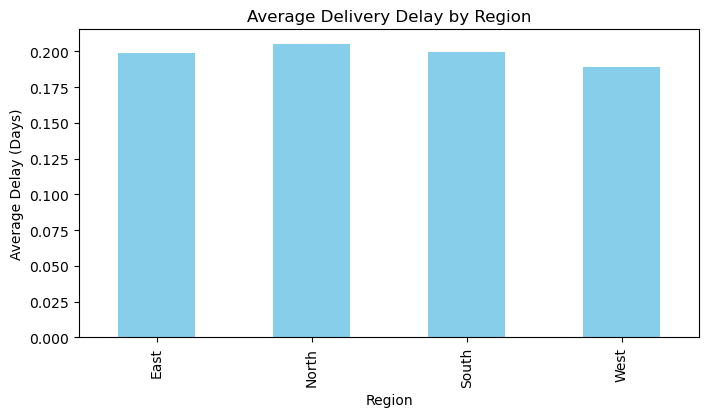

In [54]:
import matplotlib.pyplot as plt

avg_delay.plot(kind="bar", figsize=(8,4), title="Average Delivery Delay by Region", color="skyblue")
plt.ylabel("Average Delay (Days)")
plt.xlabel("Region")
plt.show()


In [56]:
import pandas as pd

inventory = pd.read_csv(r"C:\Users\suman\Data Engineer\data_science_supply_chain_dataset\ds_inventory_data.csv")

print(inventory.head())
print(inventory.columns)


  Warehouse_ID Product_ID Region  Stock_Quantity  Reorder_Level Last_Updated
0        W0037     P06251   West            1817            119   2024-06-21
1        W0016     P06538  South             171            285   2024-02-27
2        W0018     P05614   East             189             94   2024-07-24
3        W0005     P03871  South             357            366   2024-05-27
4        W0009     P08801  North            1187            105   2024-05-28
Index(['Warehouse_ID', 'Product_ID', 'Region', 'Stock_Quantity',
       'Reorder_Level', 'Last_Updated'],
      dtype='object')


In [57]:
# Make sure both columns match in name
inventory.rename(columns={"Product_ID": "product_id"}, inplace=True)

# Merge with main dataframe
inv_merge = df.merge(inventory, on="product_id", how="left")

print(inv_merge.head())


  order_id order_date product_id customer_id region  quantity  unit_price  \
0  O000001 2024-05-04     P00410       C9571   West         8     1240.51   
1  O000001 2024-05-04     P00410       C9571   West         8     1240.51   
2  O000001 2024-05-04     P00410       C9571   West         8     1240.51   
3  O000001 2024-05-04     P00410       C9571   West         8     1240.51   
4  O000001 2024-05-04     P00410       C9571   West         8     1240.51   

   discount  total_sales category subcategory    price Warehouse_ID Region  \
0      0.08      9130.15     Food   Groceries  1240.51        W0022  North   
1      0.08      9130.15     Food   Groceries  1240.51        W0042  North   
2      0.08      9130.15     Food   Groceries  1240.51        W0046   West   
3      0.08      9130.15     Food   Groceries  1240.51        W0036  South   
4      0.08      9130.15     Food   Groceries  1240.51        W0002   East   

   Stock_Quantity  Reorder_Level Last_Updated  
0             502   

In [58]:
low_stock = inv_merge[inv_merge["Stock_Quantity"] < inv_merge["Reorder_Level"]]
print("Low stock products needing reorder:\n")
print(low_stock[["product_id", "category", "Stock_Quantity", "Reorder_Level", "region"]].head(10))


Low stock products needing reorder:

   product_id     category  Stock_Quantity  Reorder_Level region
7      P00410         Food              75            313   West
18     P01917       Sports             399            405   East
30     P04068       Sports             126            460   East
38     P02860     Clothing              98            410   West
48     P07073  Electronics             313            388  North
52     P07073  Electronics             116            416  North
70     P03702         Food             471            482   West
72     P03702         Food             122            170   West
76     P03702         Food             370            379   West
92     P02969    Furniture             200            206   East


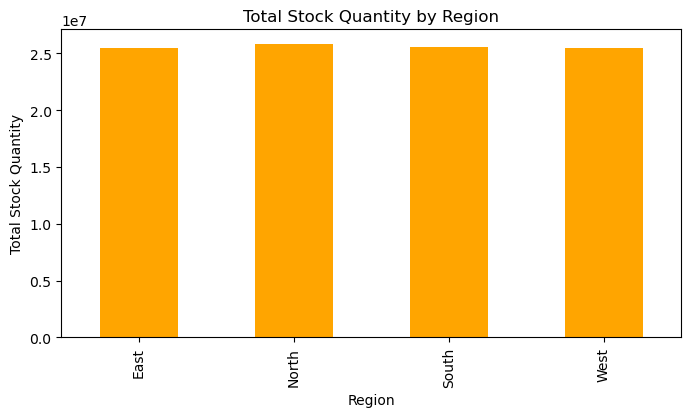

In [59]:
import matplotlib.pyplot as plt

region_stock = inventory.groupby("Region")["Stock_Quantity"].sum()

region_stock.plot(kind="bar", figsize=(8,4), title="Total Stock Quantity by Region", color="orange")
plt.ylabel("Total Stock Quantity")
plt.xlabel("Region")
plt.show()


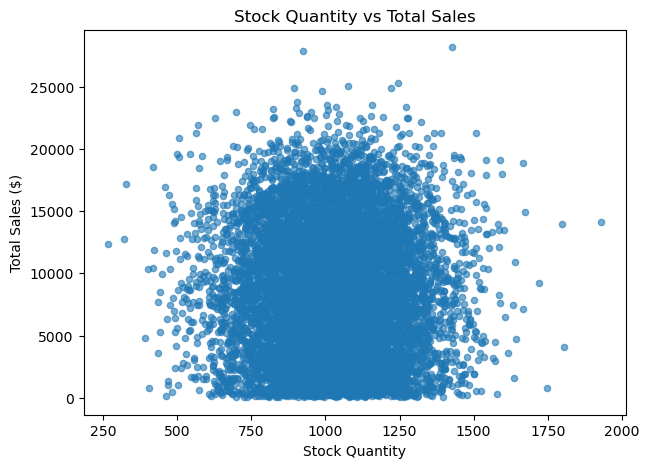

In [60]:
stock_sales = inv_merge.groupby("product_id")[["Stock_Quantity", "quantity", "total_sales"]].mean()

stock_sales.plot(kind="scatter", x="Stock_Quantity", y="total_sales", figsize=(7,5), alpha=0.6)
plt.title("Stock Quantity vs Total Sales")
plt.xlabel("Stock Quantity")
plt.ylabel("Total Sales ($)")
plt.show()


In [62]:
import os

# Define folder path
folder_path = r"C:\Users\suman\Data Engineer\processed"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

# Now save the file
output_path = os.path.join(folder_path, "final_supply_chain_analysis.csv")
inv_merge.to_csv(output_path, index=False)

print(f"✅ File successfully saved at: {output_path}")


✅ File successfully saved at: C:\Users\suman\Data Engineer\processed\final_supply_chain_analysis.csv


In [64]:
shipment["Shipment_Date"] = pd.to_datetime(shipment["Shipment_Date"])
shipment["Delivery_Date"] = pd.to_datetime(shipment["Delivery_Date"])
shipment["delivery_days"] = (shipment["Delivery_Date"] - shipment["Shipment_Date"]).dt.days


In [65]:
print("Total Sales:", df["total_sales"].sum())
print("Average Delivery Days:", shipment["delivery_days"].mean())
print("Low-stock Products:", inv_merge[inv_merge["Stock_Quantity"] < inv_merge["Reorder_Level"]].shape[0])


Total Sales: 853980418.47
Average Delivery Days: 5.48246
Low-stock Products: 115113
